# Machine Breakdown Prediction - Time Series Model Benchmarking

This notebook trains and benchmarks 4 different time series models for predicting machine breakdowns:
1. **LSTM** - Long Short-Term Memory Neural Network
2. **GRU** - Gated Recurrent Unit Neural Network
3. **Random Forest** - Traditional ML approach
4. **XGBoost** - Gradient Boosting approach

We'll train models for all 3 machines and select the best performing one.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Import deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Import XGBoost
try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
except ImportError:
    print("Installing XGBoost...")
    !pip install xgboost
    import xgboost as xgb

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

XGBoost version: 3.1.3
TensorFlow version: 2.20.0
GPU Available: []


## 1. Data Loading and Exploration

In [3]:
# Load the data
DATA_PATH = "../../DATA/Final copy.csv"
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head(10)

Dataset shape: (360, 23)

Column names: ['Unnamed: 0', 'Time', 'Captor 1', 'Captor 2', 'Captor 3', 'Captor 4', 'Captor 5', 'Captor 6', 'Captor 7', 'Captor 8', 'Captor 9', 'Captor 10', 'Captor 11', 'Captor 12', 'Captor 13', 'Captor 14', 'Captor 15', 'Captor 16', 'Captor 17', 'Captor 18', 'Machine 2', 'Machine 1', 'Machine 3']


,Unnamed: 0,Time,Captor 1,Captor 2,Captor 3,Captor 4,Captor 5,Captor 6,Captor 7,Captor 8,Captor 9,Captor 10,Captor 11,Captor 12,Captor 13,Captor 14,Captor 15,Captor 16,Captor 17,Captor 18,Machine 2,Machine 1,Machine 3
0,0,2025-06-18 11:47:10,447,1.027,4.0,0.09,3.05,0.34,1.70,114,48,64,40,43,42,66,64,63,67,72,0,1,0
1,1,2025-06-18 13:47:10,215,1.027,4.0,0.10,2.77,0.46,2.69,0,48,59,41,43,42,73,71,70,68,72,0,1,0
2,2,2025-06-18 15:47:10,344,1.029,4.3,0.17,3.18,0.57,3.65,7,49,63,42,43,42,77,75,74,72,74,1,1,0
3,3,2025-06-18 17:47:10,298,1.073,9.3,0.98,5.02,0.63,3.51,0,59,56,72,56,62,70,69,68,75,73,1,1,0
4,4,2025-06-18 19:47:10,141,1.108,14.0,1.08,5.59,0.50,3.07,1,59,55,79,58,71,55,55,53,70,70,1,1,0
5,5,2025-06-18 21:47:10,206,1.038,5.2,0.42,5.69,0.32,2.26,2,55,55,60,52,60,45,45,45,42,48,1,1,0
6,6,2025-06-18 23:47:10,275,1.066,8.2,1.16,5.72,0.30,1.46,1,62,55,72,57,66,37,37,37,71,75,1,1,0
7,7,2025-06-19 01:47:10,207,1.027,4.0,0.19,5.77,0.16,0.65,-1,54,55,56,51,57,34,34,34,44,52,0,0,0
8,8,2025-06-19 03:47:10,-1,1.026,3.8,0.03,0.69,0.25,0.61,0,53,55,39,43,42,33,33,33,57,64,0,0,0
9,9,2025-06-19 05:47:10,-1,1.026,3.8,0.05,0.15,0.34,1.77,-1,53,55,35,38,37,32,32,32,57,63,0,0,0


In [4]:
# Convert Time to datetime and set as index
df['Time'] = pd.to_datetime(df['Time'])
df = df.sort_values('Time').reset_index(drop=True)

# Display machine breakdown distribution
machines = ['Machine 1', 'Machine 2', 'Machine 3']
print("\n=== Machine Breakdown Distribution ===")
for machine in machines:
    breakdown_counts = df[machine].value_counts()
    print(f"\n{machine}:")
    print(f"  Normal (0): {breakdown_counts.get(0, 0)} ({breakdown_counts.get(0, 0)/len(df)*100:.1f}%)")
    print(f"  Breakdown (1): {breakdown_counts.get(1, 0)} ({breakdown_counts.get(1, 0)/len(df)*100:.1f}%)")


=== Machine Breakdown Distribution ===

Machine 1:
  Normal (0): 169 (46.9%)
  Breakdown (1): 191 (53.1%)

Machine 2:
  Normal (0): 260 (72.2%)
  Breakdown (1): 100 (27.8%)

Machine 3:
  Normal (0): 259 (71.9%)
  Breakdown (1): 101 (28.1%)


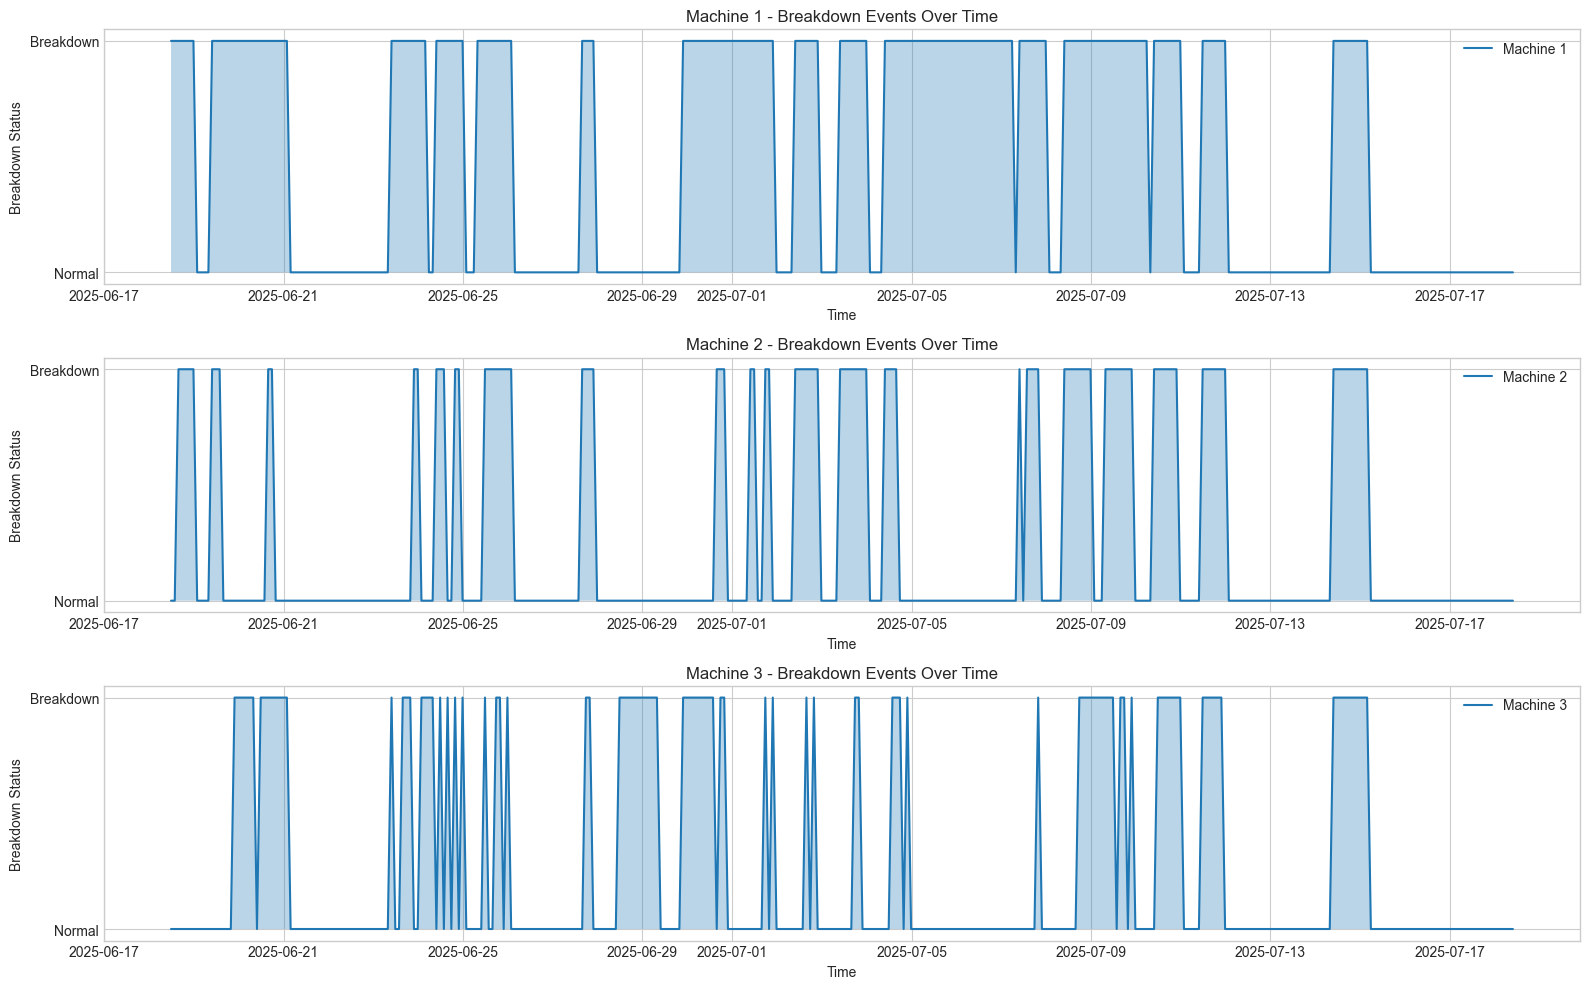

In [5]:
# Visualize the time series data
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for i, machine in enumerate(machines):
    ax = axes[i]
    ax.plot(df['Time'], df[machine], label=machine, linewidth=1.5)
    ax.fill_between(df['Time'], 0, df[machine], alpha=0.3)
    ax.set_xlabel('Time')
    ax.set_ylabel('Breakdown Status')
    ax.set_title(f'{machine} - Breakdown Events Over Time')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Normal', 'Breakdown'])
    ax.legend()

plt.tight_layout()
plt.savefig('models/machine_breakdown_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

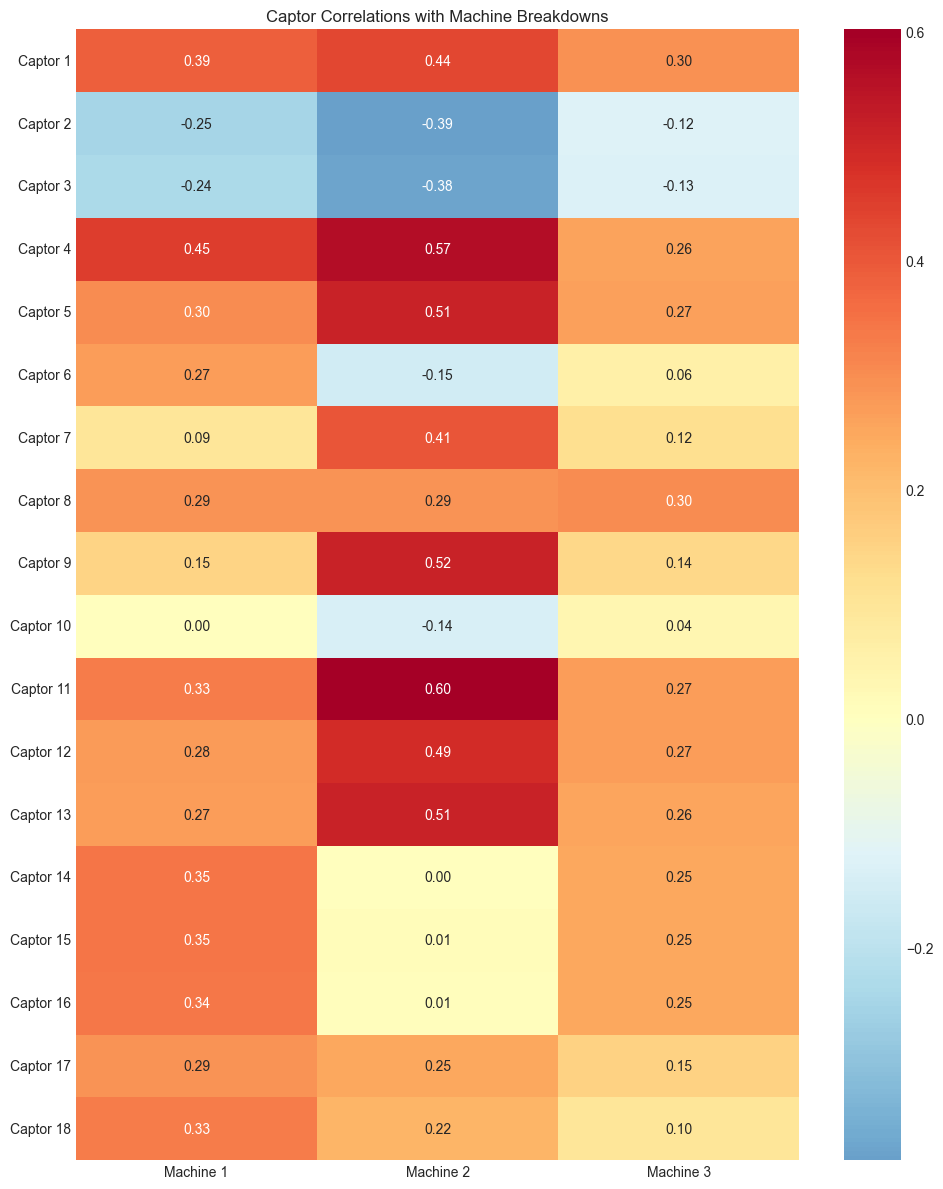

In [6]:
# Visualize captor correlations with breakdowns
captor_cols = [f'Captor {i}' for i in range(1, 19)]
correlation_data = df[captor_cols + machines].corr()

# Extract correlations with machines
machine_correlations = correlation_data.loc[captor_cols, machines]

plt.figure(figsize=(10, 12))
sns.heatmap(machine_correlations, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f')
plt.title('Captor Correlations with Machine Breakdowns')
plt.tight_layout()
plt.savefig('models/captor_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Data Preprocessing for Time Series

In [7]:
# Define feature columns
feature_cols = [f'Captor {i}' for i in range(1, 19)]

# Create time-based features
df['hour'] = df['Time'].dt.hour
df['day_of_week'] = df['Time'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Add rolling statistics for each captor
window_sizes = [3, 6, 12]  # 6h, 12h, 24h windows (2-hour intervals)

for col in feature_cols:
    for window in window_sizes:
        df[f'{col}_rolling_mean_{window}'] = df[col].rolling(window=window, min_periods=1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].rolling(window=window, min_periods=1).std().fillna(0)

# Add lag features for key captors
key_captors = ['Captor 1', 'Captor 3', 'Captor 8']  # High correlation captors
for col in key_captors:
    for lag in [1, 2, 3]:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag).fillna(method='bfill')

print(f"Enhanced dataset shape: {df.shape}")
print(f"New features: {len(df.columns) - len(feature_cols) - len(machines) - 2}")

Enhanced dataset shape: (360, 143)
New features: 120


In [8]:
# Prepare features for all models
# Get all feature columns (excluding Time and machine columns)
excluded_cols = ['Time', 'Unnamed: 0'] + machines
all_feature_cols = [col for col in df.columns if col not in excluded_cols]

print(f"Total features: {len(all_feature_cols)}")
print(f"Features: {all_feature_cols[:20]}...")  # Show first 20

# Prepare X and y
X = df[all_feature_cols].values
y = {machine: df[machine].values for machine in machines}

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nX shape: {X_scaled.shape}")
print(f"y shapes: {[(m, y[m].shape) for m in machines]}")

Total features: 138
Features: ['Captor 1', 'Captor 2', 'Captor 3', 'Captor 4', 'Captor 5', 'Captor 6', 'Captor 7', 'Captor 8', 'Captor 9', 'Captor 10', 'Captor 11', 'Captor 12', 'Captor 13', 'Captor 14', 'Captor 15', 'Captor 16', 'Captor 17', 'Captor 18', 'hour', 'day_of_week']...

X shape: (360, 138)
y shapes: [('Machine 1', (360,)), ('Machine 2', (360,)), ('Machine 3', (360,))]


In [9]:
# Create sequences for LSTM/GRU models
def create_sequences(X, y, seq_length=12):
    """Create sequences for time series models"""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# Create sequences with lookback of 12 time steps (24 hours)
SEQ_LENGTH = 12

# Store sequences for each machine
sequences = {}
for machine in machines:
    X_seq, y_seq = create_sequences(X_scaled, y[machine], SEQ_LENGTH)
    sequences[machine] = {'X': X_seq, 'y': y_seq}
    print(f"{machine} - X_seq: {X_seq.shape}, y_seq: {y_seq.shape}")

Machine 1 - X_seq: (348, 12, 138), y_seq: (348,)
Machine 2 - X_seq: (348, 12, 138), y_seq: (348,)
Machine 3 - X_seq: (348, 12, 138), y_seq: (348,)


In [10]:
# Split data using time-based split (important for time series)
def time_series_split(X, y, train_ratio=0.7, val_ratio=0.15):
    """Split data maintaining temporal order"""
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Create splits for each machine
splits = {}
for machine in machines:
    X_train, X_val, X_test, y_train, y_val, y_test = time_series_split(
        sequences[machine]['X'], 
        sequences[machine]['y']
    )
    splits[machine] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test
    }
    print(f"{machine} - Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

Machine 1 - Train: 243, Val: 52, Test: 53
Machine 2 - Train: 243, Val: 52, Test: 53
Machine 3 - Train: 243, Val: 52, Test: 53


## 3. Model Definitions

In [11]:
def build_lstm_model(input_shape, name='LSTM'):
    """Build LSTM model for binary classification"""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ], name=name)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

def build_gru_model(input_shape, name='GRU'):
    """Build GRU model for binary classification"""
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.3),
        GRU(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ], name=name)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Display model architectures
sample_shape = (SEQ_LENGTH, len(all_feature_cols))
lstm_model = build_lstm_model(sample_shape)
print("LSTM Model Architecture:")
lstm_model.summary()

LSTM Model Architecture:


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        51,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,993 (253.88 KB)

 Trainable params: 64,961 (253.75 KB)

 Non-trainable params: 32 (128.00 B)

In [12]:
gru_model = build_gru_model(sample_shape)
print("\nGRU Model Architecture:")
gru_model.summary()


GRU Model Architecture:


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        39,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,185 (192.13 KB)

 Trainable params: 49,153 (192.00 KB)

 Non-trainable params: 32 (128.00 B)

## 4. Training and Benchmarking

In [13]:
# Define callbacks
def get_callbacks(model_name, machine_name):
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ]

# Store all results
results = {}
trained_models = {}

def evaluate_model(y_true, y_pred, y_pred_proba):
    """Calculate all evaluation metrics"""
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else 0
    }

In [14]:
# Train LSTM models for all machines
print("=" * 60)
print("Training LSTM Models")
print("=" * 60)

for machine in machines:
    print(f"\n>>> Training LSTM for {machine}...")
    
    # Get data
    X_train = splits[machine]['X_train']
    X_val = splits[machine]['X_val']
    X_test = splits[machine]['X_test']
    y_train = splits[machine]['y_train']
    y_val = splits[machine]['y_val']
    y_test = splits[machine]['y_test']
    
    # Build and train model
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_lstm_model(input_shape, name=f'LSTM_{machine.replace(" ", "_")}')
    
    # Handle class imbalance
    class_weights = {0: 1.0, 1: len(y_train[y_train==0]) / max(len(y_train[y_train==1]), 1)}
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=16,
        callbacks=get_callbacks('LSTM', machine),
        class_weight=class_weights,
        verbose=1
    )
    
    # Evaluate
    y_pred_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    metrics = evaluate_model(y_test, y_pred, y_pred_proba)
    results[f'LSTM_{machine}'] = metrics
    trained_models[f'LSTM_{machine}'] = model
    
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")
    print(f"  AUC: {metrics['auc']:.4f}")

Training LSTM Models

>>> Training LSTM for Machine 1...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.6337 - auc: 0.6755 - loss: 0.5150 - val_accuracy: 0.6154 - val_auc: 0.8129 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7284 - auc: 0.8670 - loss: 0.3481 - val_accuracy: 0.5769 - val_auc: 0.7515 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8025 - auc: 0.8912 - loss: 0.3181 - val_accuracy: 0.5385 - val_auc: 0.6227 - val_loss: 0.7128 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8313 - auc: 0.9305 - loss: 0.2698 - val_accuracy: 0.5385 - val_auc: 0.6303 - val_loss: 0.7194 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8724 - auc: 0.9457 - loss: 0.2308 - val_accuracy: 0.5577 - val_auc: 0.7235 - val_loss: 0.6857 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━

In [15]:
# Train GRU models for all machines
print("=" * 60)
print("Training GRU Models")
print("=" * 60)

for machine in machines:
    print(f"\n>>> Training GRU for {machine}...")
    
    # Get data
    X_train = splits[machine]['X_train']
    X_val = splits[machine]['X_val']
    X_test = splits[machine]['X_test']
    y_train = splits[machine]['y_train']
    y_val = splits[machine]['y_val']
    y_test = splits[machine]['y_test']
    
    # Build and train model
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_gru_model(input_shape, name=f'GRU_{machine.replace(" ", "_")}')
    
    # Handle class imbalance
    class_weights = {0: 1.0, 1: len(y_train[y_train==0]) / max(len(y_train[y_train==1]), 1)}
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=16,
        callbacks=get_callbacks('GRU', machine),
        class_weight=class_weights,
        verbose=1
    )
    
    # Evaluate
    y_pred_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    metrics = evaluate_model(y_test, y_pred, y_pred_proba)
    results[f'GRU_{machine}'] = metrics
    trained_models[f'GRU_{machine}'] = model
    
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")
    print(f"  AUC: {metrics['auc']:.4f}")

Training GRU Models

>>> Training GRU for Machine 1...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.6049 - auc: 0.6213 - loss: 0.5266 - val_accuracy: 0.5385 - val_auc: 0.5788 - val_loss: 0.6895 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6996 - auc: 0.8111 - loss: 0.4209 - val_accuracy: 0.6731 - val_auc: 0.7955 - val_loss: 0.6210 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7695 - auc: 0.8881 - loss: 0.3558 - val_accuracy: 0.6346 - val_auc: 0.6682 - val_loss: 0.6560 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8560 - auc: 0.9502 - loss: 0.2978 - val_accuracy: 0.6538 - val_auc: 0.6394 - val_loss: 0.6783 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8436 - auc: 0.9247 - loss: 0.3035 - val_accuracy: 0.6538 - val_auc: 0.6689 - val_loss: 0.6730 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━

In [16]:
# Train Random Forest models for all machines
print("=" * 60)
print("Training Random Forest Models")
print("=" * 60)

for machine in machines:
    print(f"\n>>> Training Random Forest for {machine}...")
    
    # Get data - flatten sequences for RF
    X_train = splits[machine]['X_train'].reshape(splits[machine]['X_train'].shape[0], -1)
    X_test = splits[machine]['X_test'].reshape(splits[machine]['X_test'].shape[0], -1)
    y_train = splits[machine]['y_train']
    y_test = splits[machine]['y_test']
    
    # Build and train model
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    metrics = evaluate_model(y_test, y_pred, y_pred_proba)
    results[f'RF_{machine}'] = metrics
    trained_models[f'RF_{machine}'] = model
    
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")
    print(f"  AUC: {metrics['auc']:.4f}")

Training Random Forest Models

>>> Training Random Forest for Machine 1...
  Accuracy: 0.1509
  F1 Score: 0.2623
  AUC: 0.5093

>>> Training Random Forest for Machine 2...
  Accuracy: 0.4717
  F1 Score: 0.2222
  AUC: 0.4535

>>> Training Random Forest for Machine 3...
  Accuracy: 0.7736
  F1 Score: 0.0000
  AUC: 0.5349


In [17]:
# Train XGBoost models for all machines
print("=" * 60)
print("Training XGBoost Models")
print("=" * 60)

for machine in machines:
    print(f"\n>>> Training XGBoost for {machine}...")
    
    # Get data - flatten sequences for XGBoost
    X_train = splits[machine]['X_train'].reshape(splits[machine]['X_train'].shape[0], -1)
    X_val = splits[machine]['X_val'].reshape(splits[machine]['X_val'].shape[0], -1)
    X_test = splits[machine]['X_test'].reshape(splits[machine]['X_test'].shape[0], -1)
    y_train = splits[machine]['y_train']
    y_val = splits[machine]['y_val']
    y_test = splits[machine]['y_test']
    
    # Calculate scale_pos_weight for imbalanced data
    scale_pos_weight = len(y_train[y_train==0]) / max(len(y_train[y_train==1]), 1)
    
    # Build and train model
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='auc',
        early_stopping_rounds=20
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Evaluate
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    metrics = evaluate_model(y_test, y_pred, y_pred_proba)
    results[f'XGB_{machine}'] = metrics
    trained_models[f'XGB_{machine}'] = model
    
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")
    print(f"  AUC: {metrics['auc']:.4f}")

Training XGBoost Models

>>> Training XGBoost for Machine 1...
  Accuracy: 0.4151
  F1 Score: 0.3673
  AUC: 0.4535

>>> Training XGBoost for Machine 2...
  Accuracy: 0.4340
  F1 Score: 0.2857
  AUC: 0.4581

>>> Training XGBoost for Machine 3...
  Accuracy: 0.5660
  F1 Score: 0.0800
  AUC: 0.3895


## 5. Benchmarking Results

In [18]:
# Create comprehensive benchmark DataFrame
benchmark_data = []
for key, metrics in results.items():
    parts = key.split('_')
    model_type = parts[0]
    machine = ' '.join(parts[1:])
    benchmark_data.append({
        'Model': model_type,
        'Machine': machine,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1'],
        'AUC': metrics['auc']
    })

benchmark_df = pd.DataFrame(benchmark_data)
benchmark_df = benchmark_df.sort_values(['Machine', 'F1 Score'], ascending=[True, False])

print("\n" + "="*80)
print("COMPLETE BENCHMARK RESULTS")
print("="*80)
print(benchmark_df.to_string(index=False))


COMPLETE BENCHMARK RESULTS
Model   Machine  Accuracy  Precision  Recall  F1 Score      AUC
  GRU Machine 1  0.528302   0.258065     0.8  0.390244 0.832558
  XGB Machine 1  0.415094   0.230769     0.9  0.367347 0.453488
 LSTM Machine 1  0.301887   0.186047     0.8  0.301887 0.760465
   RF Machine 1  0.150943   0.156863     0.8  0.262295 0.509302
 LSTM Machine 2  0.811321   0.500000     0.7  0.583333 0.927907
  GRU Machine 2  0.716981   0.380952     0.8  0.516129 0.827907
  XGB Machine 2  0.433962   0.187500     0.6  0.285714 0.458140
   RF Machine 2  0.471698   0.153846     0.4  0.222222 0.453488
  GRU Machine 3  0.754717   0.411765     0.7  0.518519 0.825581
  XGB Machine 3  0.566038   0.066667     0.1  0.080000 0.389535
 LSTM Machine 3  0.698113   0.000000     0.0  0.000000 0.641860
   RF Machine 3  0.773585   0.000000     0.0  0.000000 0.534884


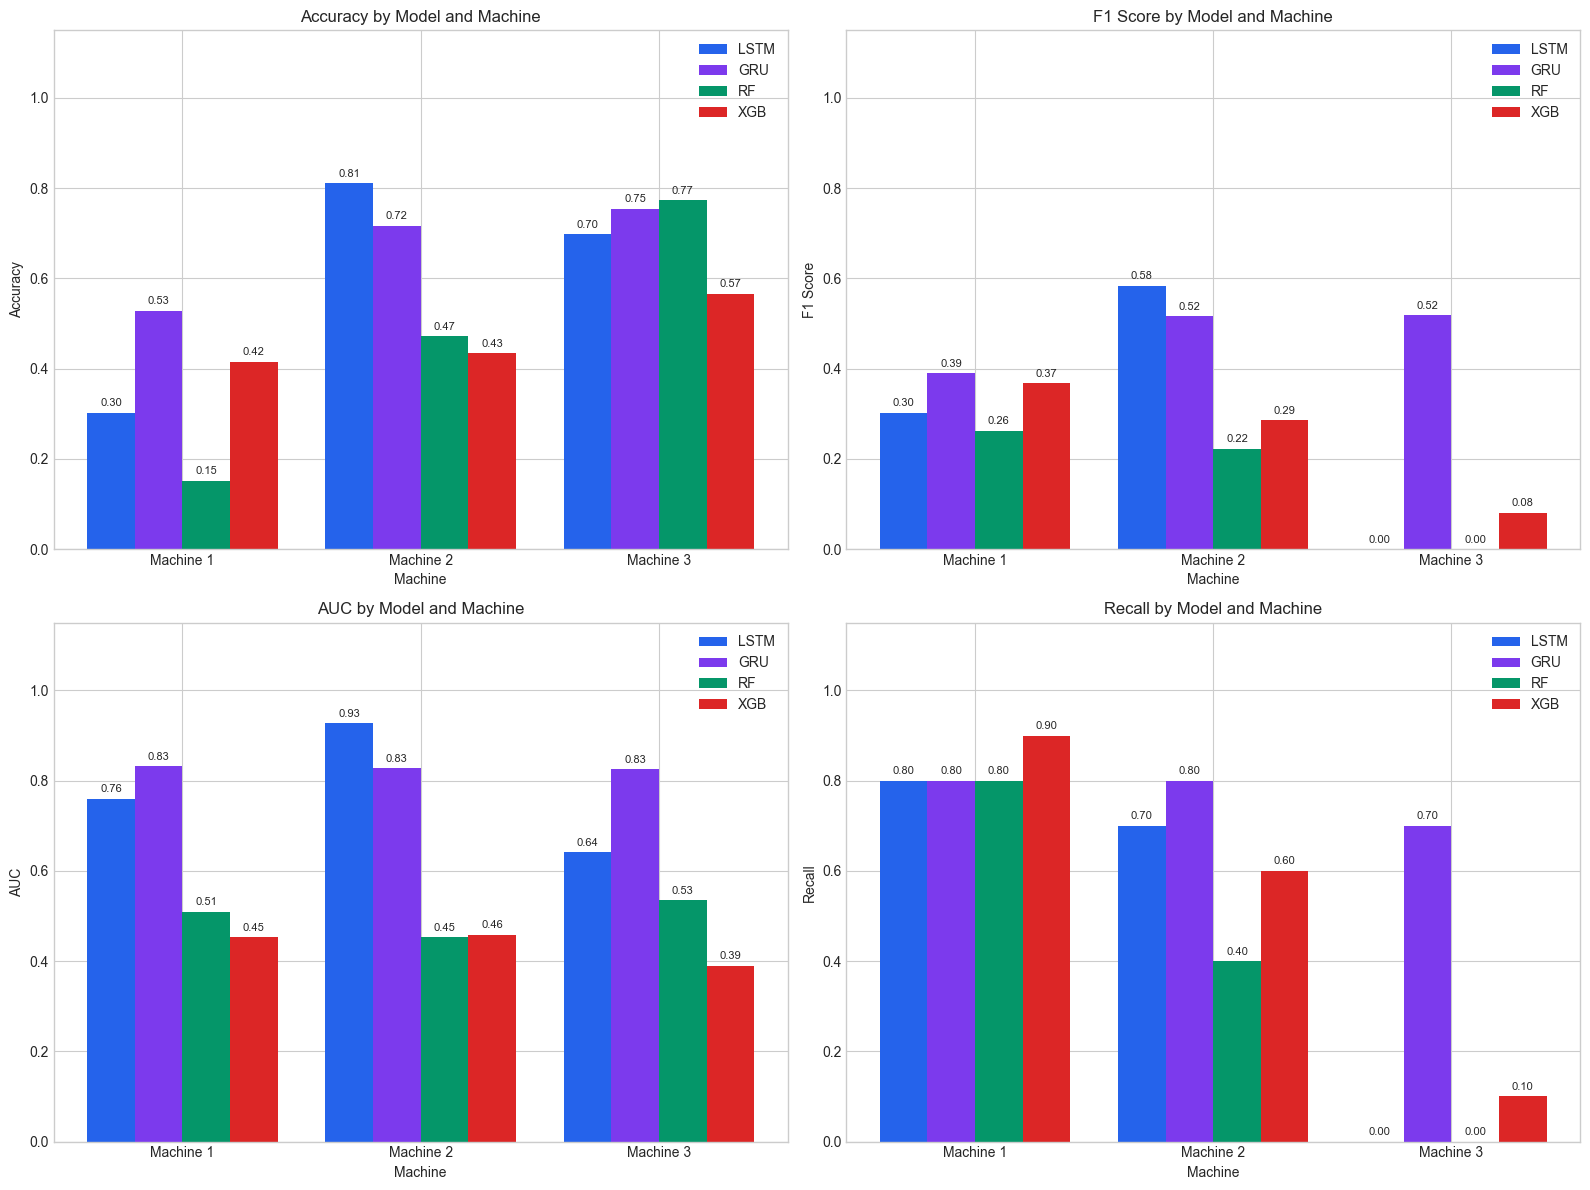

In [19]:
# Visualize benchmark results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Accuracy', 'F1 Score', 'AUC', 'Recall']
colors = {'LSTM': '#2563eb', 'GRU': '#7c3aed', 'RF': '#059669', 'XGB': '#dc2626'}

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    pivot_df = benchmark_df.pivot(index='Machine', columns='Model', values=metric)
    pivot_df = pivot_df[['LSTM', 'GRU', 'RF', 'XGB']]  # Reorder columns
    
    x = np.arange(len(pivot_df.index))
    width = 0.2
    
    for i, model in enumerate(['LSTM', 'GRU', 'RF', 'XGB']):
        bars = ax.bar(x + i * width, pivot_df[model], width, label=model, color=colors[model])
        # Add value labels
        for bar, val in zip(bars, pivot_df[model]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Machine')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Model and Machine')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(pivot_df.index)
    ax.legend()
    ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('models/benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

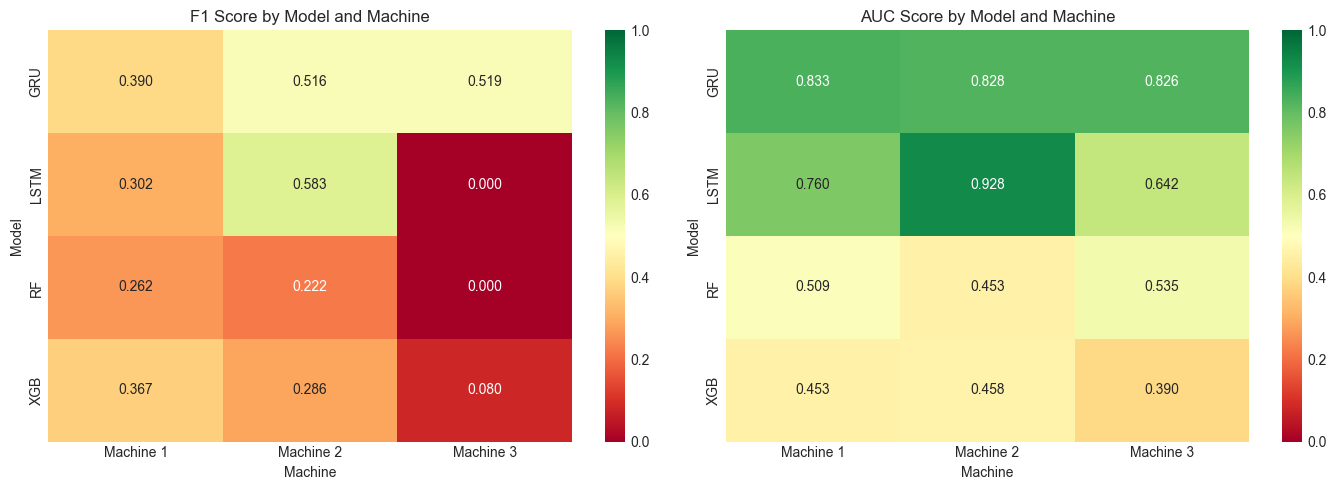

In [20]:
# Create heatmap of results
pivot_f1 = benchmark_df.pivot(index='Model', columns='Machine', values='F1 Score')
pivot_auc = benchmark_df.pivot(index='Model', columns='Machine', values='AUC')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 Score heatmap
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('F1 Score by Model and Machine')

# AUC heatmap
sns.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('AUC Score by Model and Machine')

plt.tight_layout()
plt.savefig('models/benchmark_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Determine best model for each machine
print("\n" + "="*80)
print("BEST MODEL SELECTION")
print("="*80)

best_models = {}
for machine in machines:
    machine_results = benchmark_df[benchmark_df['Machine'] == machine]
    # Select based on F1 Score (best balance of precision and recall)
    best_row = machine_results.loc[machine_results['F1 Score'].idxmax()]
    best_models[machine] = {
        'model_type': best_row['Model'],
        'metrics': {
            'accuracy': best_row['Accuracy'],
            'precision': best_row['Precision'],
            'recall': best_row['Recall'],
            'f1': best_row['F1 Score'],
            'auc': best_row['AUC']
        }
    }
    print(f"\n{machine}:")
    print(f"  Best Model: {best_row['Model']}")
    print(f"  F1 Score: {best_row['F1 Score']:.4f}")
    print(f"  AUC: {best_row['AUC']:.4f}")
    print(f"  Accuracy: {best_row['Accuracy']:.4f}")


BEST MODEL SELECTION

Machine 1:
  Best Model: GRU
  F1 Score: 0.3902
  AUC: 0.8326
  Accuracy: 0.5283

Machine 2:
  Best Model: LSTM
  F1 Score: 0.5833
  AUC: 0.9279
  Accuracy: 0.8113

Machine 3:
  Best Model: GRU
  F1 Score: 0.5185
  AUC: 0.8256
  Accuracy: 0.7547


In [22]:
# Calculate average performance across all machines
avg_performance = benchmark_df.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']].mean()
avg_performance['Overall'] = avg_performance.mean(axis=1)
avg_performance = avg_performance.sort_values('Overall', ascending=False)

print("\n" + "="*80)
print("AVERAGE PERFORMANCE ACROSS ALL MACHINES")
print("="*80)
print(avg_performance.to_string())

# Determine overall best model
overall_best_model = avg_performance['Overall'].idxmax()
print(f"\n>>> OVERALL BEST MODEL: {overall_best_model}")
print(f"    Average F1 Score: {avg_performance.loc[overall_best_model, 'F1 Score']:.4f}")
print(f"    Average AUC: {avg_performance.loc[overall_best_model, 'AUC']:.4f}")


AVERAGE PERFORMANCE ACROSS ALL MACHINES
       Accuracy  Precision    Recall  F1 Score       AUC   Overall
Model                                                             
GRU    0.666667   0.350261  0.766667  0.474964  0.828682  0.617448
LSTM   0.603774   0.228682  0.500000  0.295073  0.776744  0.480855
XGB    0.471698   0.161645  0.533333  0.244354  0.433721  0.368950
RF     0.465409   0.103570  0.400000  0.161506  0.499225  0.325942

>>> OVERALL BEST MODEL: GRU
    Average F1 Score: 0.4750
    Average AUC: 0.8287


## 6. Save Best Models

In [23]:
import joblib
import json
import os

# Create models directory if needed
os.makedirs('models', exist_ok=True)

# Save the best model for each machine based on the overall best model type
model_info = {
    'best_model_type': overall_best_model,
    'seq_length': SEQ_LENGTH,
    'feature_cols': all_feature_cols,
    'machines': machines,
    'benchmark_results': benchmark_df.to_dict('records'),
    'models': {}
}

print("Saving best models...")

for machine in machines:
    machine_key = f"{overall_best_model}_{machine}"
    model = trained_models[machine_key]
    
    # Save based on model type
    safe_name = machine.replace(' ', '_').lower()
    
    if overall_best_model in ['LSTM', 'GRU']:
        model_path = f'models/best_{safe_name}_model.keras'
        model.save(model_path)
    else:
        model_path = f'models/best_{safe_name}_model.joblib'
        joblib.dump(model, model_path)
    
    model_info['models'][machine] = {
        'path': model_path,
        'type': overall_best_model,
        'metrics': results[machine_key]
    }
    print(f"  Saved {machine} model to {model_path}")

# Save scaler
joblib.dump(scaler, 'models/feature_scaler.joblib')
print("  Saved scaler to models/feature_scaler.joblib")

# Save model info
with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2, default=str)
print("  Saved model info to models/model_info.json")

print("\n✅ All models saved successfully!")

Saving best models...
  Saved Machine 1 model to models/best_machine_1_model.keras
  Saved Machine 2 model to models/best_machine_2_model.keras
  Saved Machine 3 model to models/best_machine_3_model.keras
  Saved scaler to models/feature_scaler.joblib
  Saved model info to models/model_info.json

✅ All models saved successfully!


Benchmark report saved to models/benchmark_report.csv


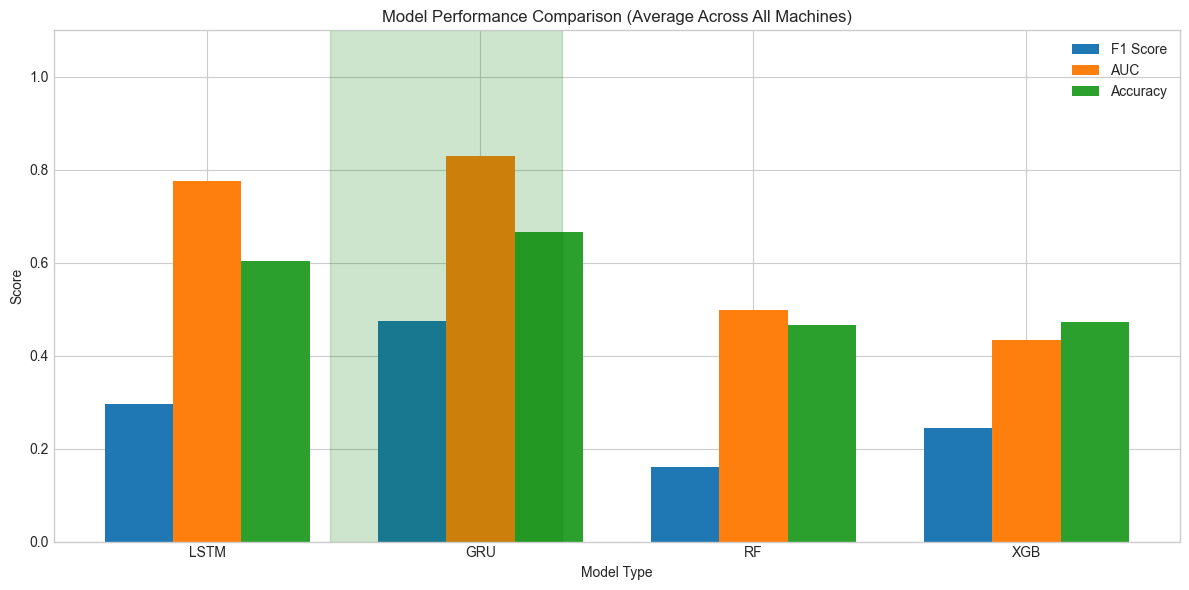


🏆 FINAL SELECTION: GRU model saved for all machines!


In [24]:
# Save benchmark report as CSV
benchmark_df.to_csv('models/benchmark_report.csv', index=False)
print("Benchmark report saved to models/benchmark_report.csv")

# Create summary visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped bar chart showing best model performance
models = ['LSTM', 'GRU', 'RF', 'XGB']
x = np.arange(len(models))
width = 0.25

for i, metric in enumerate(['F1 Score', 'AUC', 'Accuracy']):
    values = [avg_performance.loc[m, metric] for m in models]
    bars = ax.bar(x + i * width, values, width, label=metric)

ax.set_xlabel('Model Type')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Average Across All Machines)')
ax.set_xticks(x + width)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)

# Highlight best model
best_idx = models.index(overall_best_model)
ax.axvspan(best_idx - 0.3, best_idx + 0.55, alpha=0.2, color='green', label='Best Model')

plt.tight_layout()
plt.savefig('models/final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 FINAL SELECTION: {overall_best_model} model saved for all machines!")

## 7. Test Prediction Function

In [25]:
def predict_breakdown(X_input, machine_name, model, scaler, model_type, seq_length=12):
    """
    Make breakdown prediction for a single machine.
    
    Args:
        X_input: Input features (raw, unscaled)
        machine_name: Name of the machine
        model: Trained model
        scaler: Fitted scaler
        model_type: Type of model ('LSTM', 'GRU', 'RF', 'XGB')
        seq_length: Sequence length for LSTM/GRU models
    
    Returns:
        Prediction probability (0-1)
    """
    # Scale input
    X_scaled = scaler.transform(X_input)
    
    if model_type in ['LSTM', 'GRU']:
        # Reshape for sequence models
        if len(X_scaled) < seq_length:
            # Pad with zeros if not enough data
            padding = np.zeros((seq_length - len(X_scaled), X_scaled.shape[1]))
            X_scaled = np.vstack([padding, X_scaled])
        X_seq = X_scaled[-seq_length:].reshape(1, seq_length, -1)
        pred = model.predict(X_seq, verbose=0)[0][0]
    else:
        # Flatten for traditional ML models
        if len(X_scaled) < seq_length:
            padding = np.zeros((seq_length - len(X_scaled), X_scaled.shape[1]))
            X_scaled = np.vstack([padding, X_scaled])
        X_flat = X_scaled[-seq_length:].flatten().reshape(1, -1)
        pred = model.predict_proba(X_flat)[0][1]
    
    return float(pred)

# Test the prediction function
print("Testing prediction function...")

# Get sample data
sample_data = df[all_feature_cols].iloc[:SEQ_LENGTH].values

for machine in machines:
    model_key = f"{overall_best_model}_{machine}"
    model = trained_models[model_key]
    
    pred = predict_breakdown(sample_data, machine, model, scaler, overall_best_model, SEQ_LENGTH)
    risk_level = 'High' if pred >= 0.7 else 'Medium' if pred >= 0.4 else 'Low'
    
    print(f"{machine}: {pred:.4f} ({risk_level} Risk)")

print("\n✅ Prediction function working correctly!")

Testing prediction function...
Machine 1: 0.9384 (High Risk)
Machine 2: 0.4345 (Medium Risk)
Machine 3: 0.1396 (Low Risk)

✅ Prediction function working correctly!


## Summary

This notebook has:
1. ✅ Loaded and preprocessed the machine sensor data
2. ✅ Created time-based features (rolling statistics, lag features)
3. ✅ Trained 4 different models (LSTM, GRU, Random Forest, XGBoost) for all 3 machines
4. ✅ Benchmarked all models using Accuracy, Precision, Recall, F1 Score, and AUC
5. ✅ Selected the best performing model based on F1 Score
6. ✅ Saved the best models, scaler, and configuration
7. ✅ Created visualizations for benchmark comparison

The saved models can now be used by the FastAPI prediction endpoint.